# Experiments on Modelling Between 2019 and 2025 Snapshots

This notebook is for investigating how models perform when extending the dataset to include two snapshots instead of one.

There are two years with published IMD scores from the ONS, these being 2019 and 2025. Unfortunately, due to changing methodologies, direct score comparison cannot be made between the two but lsoa rankings are viable. Due to this, validation will have to be against rank even if training is on score.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

from scipy.stats import spearmanr, pearsonr


RANDOM_STATE = 19


## Load and Clean Datasets

### Load Datasets

In [39]:
# Load dataset and imd to create merged dataset with target variable

indicators_2019 = pd.read_parquet('combined_indicators_2019.parquet', engine='fastparquet')
indicators_2025 = pd.read_parquet('combined_indicators_2025.parquet', engine='fastparquet')

scores_2019 = pd.read_csv('imd_2019_scores.csv')
scores_2025 = pd.read_csv('imd_2025_scores.csv')

lsoa_lookup = pd.read_csv('lsoa_2011_2021_lookup.csv')



### Clean Datasets

In [40]:
scores_2019.rename(columns={'LSOA code (2011)': 'lsoa_code_11',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

# lsoa codes were changed in 2021, so 2019 codes are converted to 2021 codes using the lookup table
scores_2019 = scores_2019.merge(lsoa_lookup[['lsoa_code_11', 'lsoa_code_21']], on='lsoa_code_11', how='right')
scores_2019.drop(columns=['lsoa_code_11'], inplace=True)
scores_2019.rename(columns={'lsoa_code_21': 'lsoa_code'}, inplace=True)


scores_2025.rename(columns={'LSOA code (2021)': 'lsoa_code',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

scores_2019 = scores_2019[['lsoa_code', 'imd_score']]
scores_2025 = scores_2025[['lsoa_code', 'imd_score']]

# Merge features and target datasets on 'lsoa_code'
data_2019 = pd.merge(indicators_2019, scores_2019, on='lsoa_code')
data_2025 = pd.merge(indicators_2025, scores_2025, on='lsoa_code', how='left')

#### Drop Missaligned Features

In [41]:
# Ensure features are consistent between datasets
common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
data_2019 = data_2019[common_features]
data_2025 = data_2025[common_features]

In [42]:
# Check that now datasets have the same shape
data_2019.shape == data_2025.shape   

True

#### Deal with Null, NaN and Inf

First infinite values are replaced with NaN

In [43]:
if np.isinf(data_2019.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2019 dataset, replaced with NaN.")
    data_2019.replace([np.inf, -np.inf], np.nan, inplace=True) 

if np.isinf(data_2025.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2025 dataset.")
    data_2025.replace([np.inf, -np.inf], np.nan, inplace=True)

Check missingness and drop features with >20% missing values, then impute remaining missing values with median

In [44]:
# 2019

missingness = data_2019.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2019)) * 100
missingness_df_2019 = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2019 = data_2019.drop(columns=missingness_df_2019[missingness_df_2019['missing_percent'] > 20]['feature'])
data_2019 = data_2019.fillna(data_2019.median(numeric_only=True)) 

missingness_df_2019.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,resolution_rate,268,100.000000
1,ratio_fast_food_takeaway_to_food_dining_500,36,13.432836
2,ratio_sustainable_transport_to_transport_car_1000,27,10.074627
3,ratio_fast_food_takeaway_to_healthcare_access_...,22,8.208955
4,ratio_alcohol_gambling_to_financial_services_500,22,8.208955
5,bicycle-theft,9,3.358209
6,robbery,9,3.358209
7,Awaiting court outcome,9,3.358209
8,Unable to prosecute suspect,9,3.358209
9,Status update unavailable,9,3.358209


In [45]:
# 2025

missingness = data_2025.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2025)) * 100
missingness_2025_df = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2025 = data_2025.drop(columns=missingness_2025_df[missingness_2025_df['missing_percent'] > 20]['feature'])
data_2025 = data_2025.fillna(data_2025.median(numeric_only=True)) 

missingness_2025_df.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,count_professional_services_1250,0,0.0
1,count_essential_services_1000,0,0.0
2,count_financial_services_2500,0,0.0
3,count_healthcare_access_2000,0,0.0
4,count_transport_public_5000,0,0.0
5,count_essential_services_750,0,0.0
6,count_essential_services_2500,0,0.0
7,count_childcare_early_years_1250,0,0.0
8,count_social_support_1250,0,0.0
9,count_waste_sanitation_1000,0,0.0


In [46]:
# Ensure datasets still have the same shape after dropping features with high missingness
consistent_shape = data_2019.shape == data_2025.shape

print(f"Datasets have consistent shapes: {consistent_shape}")

if not consistent_shape:
    # redo the common features step to ensure both datasets have the same features after dropping those with high missingness
    common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
    data_2019 = data_2019[common_features]
    data_2025 = data_2025[common_features]


Datasets have consistent shapes: False


In [47]:
data_2019.set_index("lsoa_code", inplace=True)
data_2025.set_index("lsoa_code", inplace=True)

X_2019 = data_2019.drop(columns=['imd_score'])
y_2019 = data_2019['imd_score']

X_2025 = data_2025.drop(columns=['imd_score'])
y_2025 = data_2025['imd_score']

## Exploratory Analysis

### Target Distribution

Start by observing dsitribution on scores.

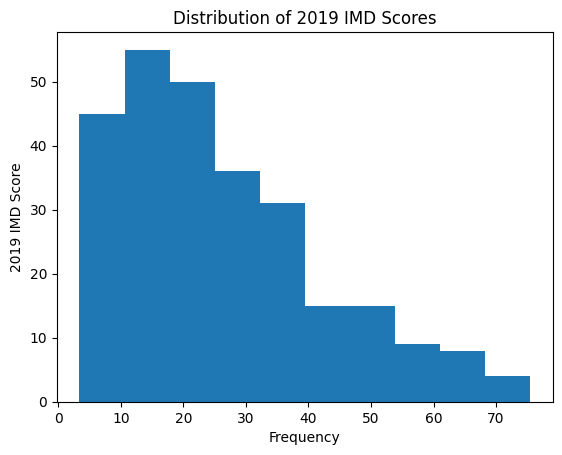

In [48]:
plt.figure()
plt.hist(y_2019, bins=10)
plt.ylabel("2019 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2019 IMD Scores")
plt.show()

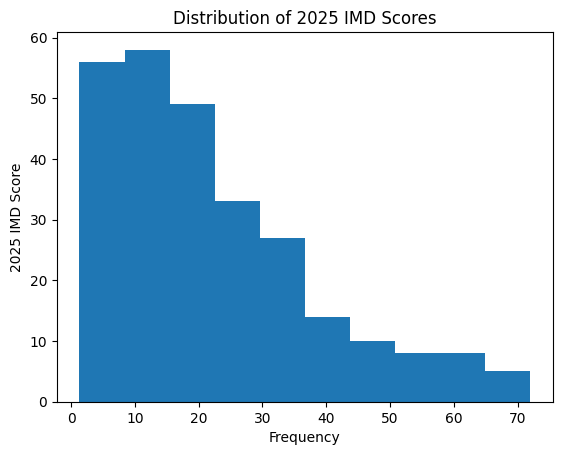

In [49]:
plt.figure()
plt.hist(y_2025, bins=10)
plt.ylabel("2025 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2025 IMD Scores")
plt.show()

Though as noted, methodology changed between the two reports, scores seem to follow similar scale and distribution. For modeling, the postive skew is removed with a log transformation.

In [50]:
y_log_2019 = np.log1p(y_2019)
y_log_2025 = np.log1p(y_2025)

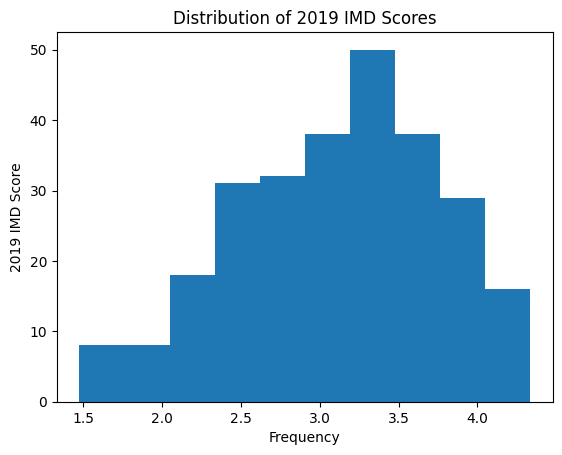

In [51]:
plt.figure()
plt.hist(y_log_2019, bins=10)
plt.ylabel("2019 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2019 IMD Scores")
plt.show()

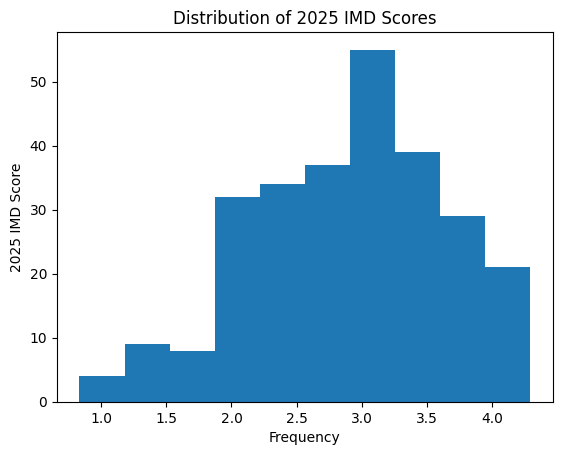

In [52]:
plt.figure()
plt.hist(y_log_2025, bins=10)
plt.ylabel("2025 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2025 IMD Scores")
plt.show()

Similarity in distribution is now even more striking. To check train and validation splits will have some difference, correlation and scatter of scores is checked.

In [53]:
corr, p_value = pearsonr(y_log_2019, y_log_2025)
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.05330096183052957
P-value: 0.38478492480270643


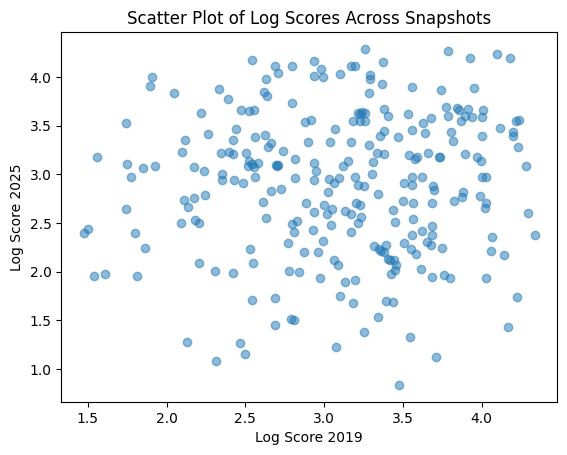

In [54]:
plt.scatter(y_log_2019, y_log_2025, alpha=0.5)
plt.xlabel("Log Score 2019")
plt.ylabel("Log Score 2025")
plt.title("Scatter Plot of Log Scores Across Snapshots")
plt.show()

### Feature Correlations

In [55]:
numeric_features_2019 = data_2019.select_dtypes(include=['number'])
numeric_features_2025 = data_2025.select_dtypes(include=['number'])

print(numeric_features_2019.corr().shape, numeric_features_2025.corr().shape) # these should be the same from previous cleaning steps
print("total number of correlations:", numeric_features_2019.size)



(340, 340) (340, 340)
total number of correlations: 91120


Due to large shape visualising as a full heatmap would be innefective. Instead correlation is checked through tables.

In [56]:

corr_with_target_2019 = numeric_features_2019.corr()["imd_score"].abs().sort_values(ascending=False)
corr_with_target_2025 = numeric_features_2025.corr()["imd_score"].abs().sort_values(ascending=False)

corr_with_target_2019 = corr_with_target_2019.drop("imd_score")
corr_with_target_2025 = corr_with_target_2025.drop("imd_score")

print("With target (2019):",end="\n\n")
print(corr_with_target_2019.head(10))
print("\nWith target (2025):",end="\n\n")
print(corr_with_target_2025.head(10))


With target (2019):

total_nwr_claims              0.911166
mean_monthly_nwr_claims       0.911166
total_claims                  0.889190
mean_monthly_claims           0.889190
mean_monthly_prepfw_claims    0.834038
total_prepfw_claims           0.834038
mean_monthly_planfw_claims    0.723200
total_planfw_claims           0.723200
mean_monthly_sfw_claims       0.698193
total_sfw_claims              0.698193
Name: imd_score, dtype: float64

With target (2025):

total_nwr_claims              0.930357
mean_monthly_nwr_claims       0.930357
total_claims                  0.909689
mean_monthly_claims           0.909689
total_prepfw_claims           0.860501
mean_monthly_prepfw_claims    0.860501
total_planfw_claims           0.769796
mean_monthly_planfw_claims    0.769796
mean_monthly_sfw_claims       0.713258
total_sfw_claims              0.713258
Name: imd_score, dtype: float64


Seeing that correlation on UC metrics are almost perfect, a scatterplot is produced. Note that since correlation was taken against the non-log transformed target, the standard target is used for the plot too.

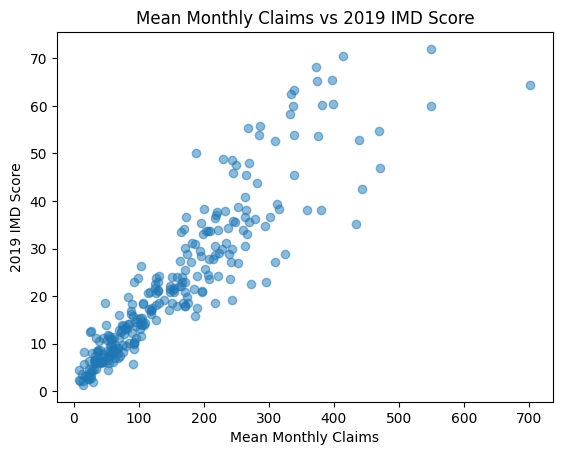

In [57]:
plt.scatter(data_2025[["mean_monthly_claims"]], y_2025, alpha=0.5)
plt.xlabel("Mean Monthly Claims")
plt.ylabel("2019 IMD Score")
plt.title("Mean Monthly Claims vs 2019 IMD Score")
plt.show()

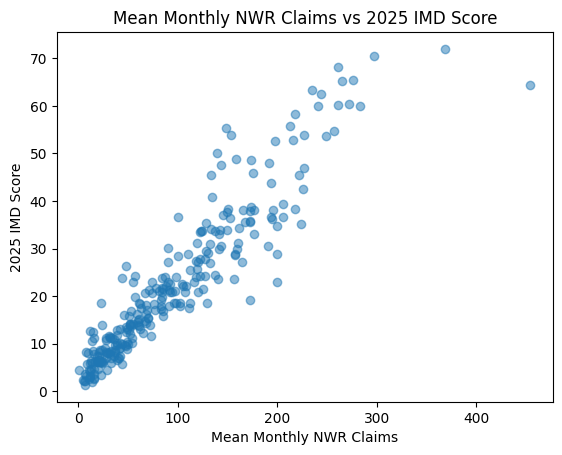

In [58]:
plt.scatter(data_2025[["mean_monthly_nwr_claims"]], y_2025, alpha=0.5)
plt.xlabel("Mean Monthly NWR Claims")
plt.ylabel("2025 IMD Score")  
plt.title("Mean Monthly NWR Claims vs 2025 IMD Score")
plt.show()

Seeing this, it is expected models should perform very well. Possibly to an extent which otherwise would appear to be overfitting. With a dataset of the shape p >> n, it was expected that the feature space would have to be reduced down by PCA, factor analysis or another method. On seeing these high correlations, it may even be sufficient to just select raw features using correlation scores. Regardless, both options will be explored. For PCA, correlations between features should be checked.

In [59]:
corr_2019 = numeric_features_2019.corr().abs()
corr_2025 = numeric_features_2025.corr().abs()

def corr_count(corr_matrix, threshold):
    count = corr_matrix[corr_matrix > threshold].count().sum() - len(corr_matrix)  # subtract self-correlations
    return count

count_2019 = corr_count(corr_2019, 0.8)
count_2025 = corr_count(corr_2025, 0.8)

print(f"Number of feature pairs with absolute correlation > 0.8 in 2019: {count_2019}")
print(f"As a percentage of total correlations: {count_2019 / numeric_features_2019.size:.2%}", end="\n\n")

print(f"Number of feature pairs with absolute correlation > 0.8 in 2025: {count_2025}")
print(f"As a percentage of total correlations: {count_2025 / numeric_features_2025.size:.2%}")


Number of feature pairs with absolute correlation > 0.8 in 2019: 9681
As a percentage of total correlations: 10.62%

Number of feature pairs with absolute correlation > 0.8 in 2025: 7864
As a percentage of total correlations: 8.63%


Observing about a third of absoloute correlations in the feature space for both snapshots is over 0.8, analysis is repeated on a threshold of 0.5

In [60]:
count_2019 = corr_count(corr_2019, 0.5)
count_2025 = corr_count(corr_2025, 0.5)

print(f"Number of feature pairs with absolute correlation > 0.5 in 2019: {count_2019}")
print(f"As a percentage of total correlations: {count_2019 / numeric_features_2019.size:.2%}", end="\n\n")

print(f"Number of feature pairs with absolute correlation > 0.5 in 2025: {count_2025}")
print(f"As a percentage of total correlations: {count_2025 / numeric_features_2025.size:.2%}")

Number of feature pairs with absolute correlation > 0.5 in 2019: 31417
As a percentage of total correlations: 34.48%

Number of feature pairs with absolute correlation > 0.5 in 2025: 29528
As a percentage of total correlations: 32.41%


With this, about 60% of correlations are found to be of some importance.

These measures indicate high multicolinearity. While this may be less of an issue for tree-based models, regression models will be unstable. To accomodate for this, PCA will be used since it produces orthogonal features.

### Encode Categorical Features

Before modelling or feature reduction categorical features need to be encoded.

In [61]:
categorical_cols = data_2019.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(categorical_cols))

numeric_features_2019.shape, data_2019.shape

Categorical columns: []


((268, 340), (268, 340))

WIth no categorical features, reduction can happen on whole feature space without encoding.

## Feature Reduction

In [62]:
# Scale
scaler = StandardScaler()
X_scaled_2019 = scaler.fit_transform(X_2019)
X_scaled_2025 = scaler.fit_transform(X_2025)

### PCA

In [63]:
components_to_try = [100, 50, 20, 10]

X_pca_100_2019, X_pca_50_2019, X_pca_20_2019, X_pca_10_2019 = [pca.fit_transform(X_scaled_2019) for pca in [PCA(n_components=n) for n in components_to_try]]
X_pca_100_2025, X_pca_50_2025, X_pca_20_2025, X_pca_10_2025 = [pca.fit_transform(X_scaled_2025) for pca in [PCA(n_components=n) for n in components_to_try]]

Number of components 95% (2019): 66


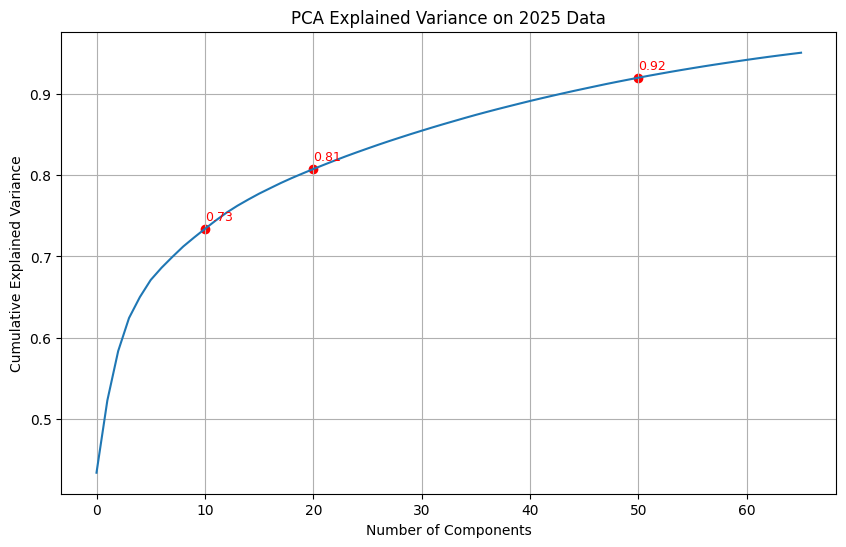

In [64]:
pca_pct_95 = PCA(n_components=0.95)  # keep 95% variance
X_pca_pct_95_2019 = pca_pct_95.fit_transform(X_scaled_2019)
print("Number of components 95% (2019):", pca_pct_95.n_components_)

cum_var = np.cumsum(pca_pct_95.explained_variance_ratio_)

plt.figure(figsize=(10,6))
plt.plot(cum_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance on 2025 Data")
plt.grid(True)

# Annotate specific component points
for c in components_to_try:
    if c <= len(cum_var):  # avoid index error
        plt.scatter(c, cum_var[c], color='red')  # -1 because Python indexing
        plt.text(c, cum_var[c]+0.01, f"{cum_var[c]:.2f}", color='red', fontsize=9)

Number of components 95% (2025): 71


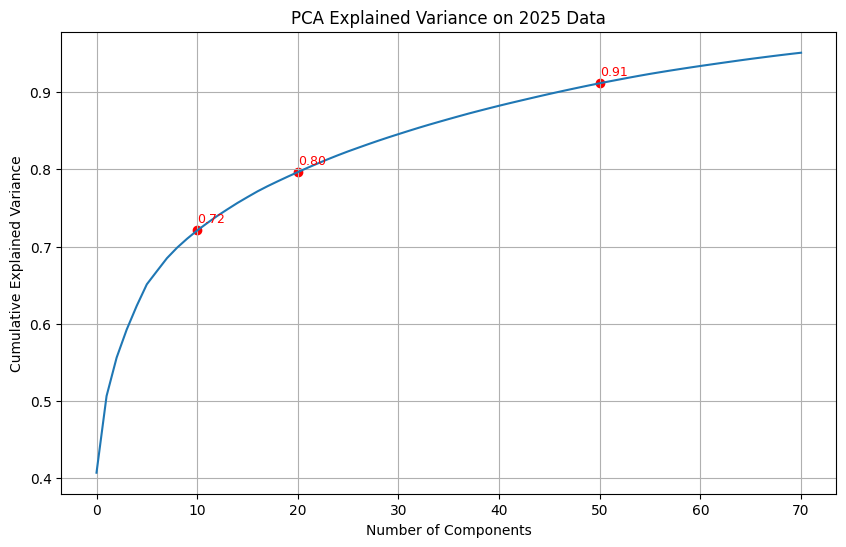

In [65]:
X_pca_pct_95_2025 = pca_pct_95.fit_transform(X_scaled_2025)
print("Number of components 95% (2025):", pca_pct_95.n_components_)

cum_var = np.cumsum(pca_pct_95.explained_variance_ratio_)

plt.figure(figsize=(10,6))
plt.plot(cum_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance on 2025 Data")
plt.grid(True)

# Annotate specific component points
for c in components_to_try:
    if c <= len(cum_var):  # avoid index error
        plt.scatter(c, cum_var[c], color='red')  # -1 because Python indexing
        plt.text(c, cum_var[c]+0.01, f"{cum_var[c]:.2f}", color='red', fontsize=9)

### Factor Analysis

In [66]:
fa_10 = FactorAnalysis(n_components=10, random_state=RANDOM_STATE) 
fa_20 = FactorAnalysis(n_components=20, random_state=RANDOM_STATE)
fa_30 = FactorAnalysis(n_components=30, random_state=RANDOM_STATE)
fa_5 = FactorAnalysis(n_components=5, random_state=RANDOM_STATE)



X_fa_10_2019 = fa_10.fit_transform(X_scaled_2019)
X_fa_20_2019 = fa_20.fit_transform(X_scaled_2019)
X_fa_30_2019 = fa_30.fit_transform(X_scaled_2019)
X_fa_5_2019 = fa_5.fit_transform(X_scaled_2019)

X_fa_10_2025 = fa_10.fit_transform(X_scaled_2025)
X_fa_20_2025 = fa_20.fit_transform(X_scaled_2025)
X_fa_30_2025 = fa_30.fit_transform(X_scaled_2025)
X_fa_5_2025 = fa_5.fit_transform(X_scaled_2025)

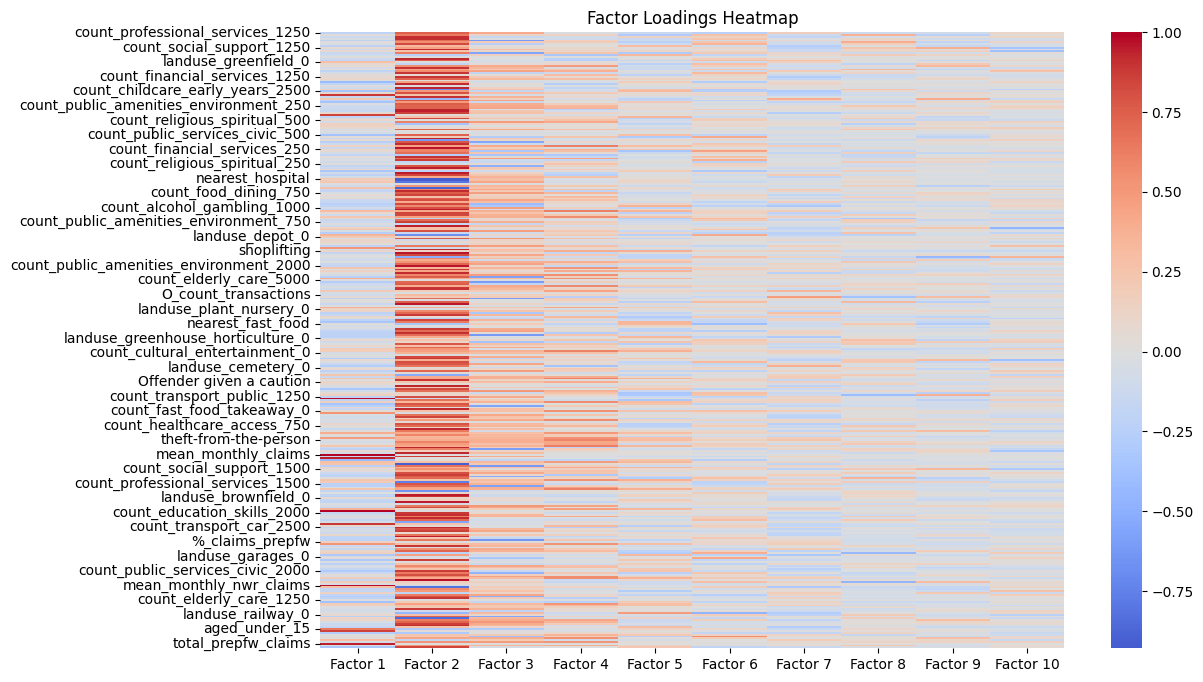

In [67]:
# Factor loadings
loadings = pd.DataFrame(fa_10.components_.T, index=X_2019.columns, columns=[f'Factor {i+1}' for i in range(10)])

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, cmap='coolwarm', center=0)
plt.title("Factor Loadings Heatmap")
plt.show()

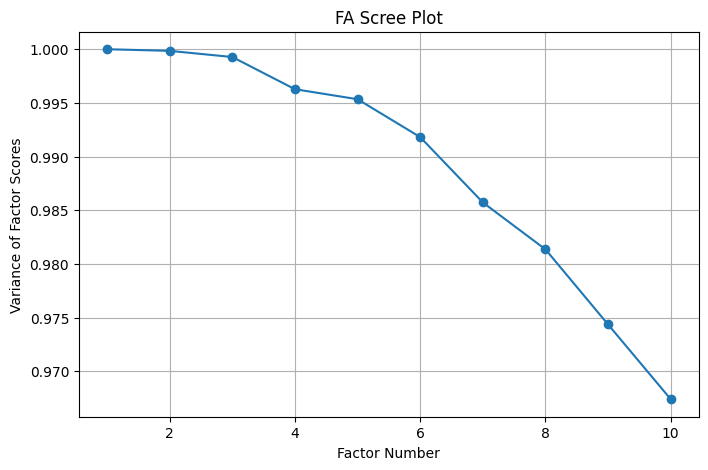

In [86]:
factor_variances = np.var(X_fa_10_2019, axis=0)

plt.figure(figsize=(8,5))
plt.plot(range(1, 10+1), factor_variances, marker='o')
plt.xlabel("Factor Number")
plt.ylabel("Variance of Factor Scores")
plt.title("FA Scree Plot")
plt.grid(True)
plt.show()

On seeing loadings being dominated in the first two factors and variance drop only very slightly, it is understood that succesive factors don't increase information in the dataset. It also confirms from previous analysis that dataset is highly correlated which may be dominated by one strong signal.

## Modelling

### Setup

In [78]:
reduced_sets_2019 = {
    'pca_100': X_pca_100_2019,
    'pca_50': X_pca_50_2019,
    'pca_20': X_pca_20_2019,
    'pca_10': X_pca_10_2019, 
    'scaled': X_scaled_2019, 
    'fa_10': X_fa_10_2019,
    'fa_20': X_fa_20_2019,
    'fa_30': X_fa_30_2019,
    'fa_5': X_fa_5_2019
}
reduced_sets_2025 = {
    'pca_100': X_pca_100_2025,
    'pca_50': X_pca_50_2025,
    'pca_20': X_pca_20_2025, 
    'pca_10': X_pca_10_2025, 
    'scaled': X_scaled_2025, 
    'fa_10': X_fa_10_2025, 
    'fa_20': X_fa_20_2025, 
    'fa_30': X_fa_30_2025, 
    'fa_5': X_fa_5_2025
}

results_df = pd.DataFrame(columns=['model', 'train_r2_mean', 'val_spearman', 'param'])

# For Ridge
alphas = [0.1, 1.0, 10.0, 100.0]  

# For Random Forest
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [5, 10],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2', 0.3, 0.5]
}

### CV on 2019 and Validation on 2025

#### Ridge Regression

In [79]:
for key in reduced_sets_2019:

    X_train = reduced_sets_2019[key]
    y_train = y_log_2019

    X_test = reduced_sets_2025[key]
    y_test = y_log_2025

    for a in alphas:
        ridge = Ridge(alpha=a, random_state=42)

        # Cross-validation on training (2019)
        cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
        train_r2_mean = cv_scores.mean()

        # Fit on full 2019
        ridge.fit(X_train, y_train)

        # Validate on 2025
        y_pred = ridge.predict(X_test)
        spearman_rank, p = spearmanr(y_test, y_pred)
        if p < 0.05:
            results_df = pd.concat([results_df, pd.DataFrame({
                'model': ['Ridge'],
                'train_r2_mean': [train_r2_mean],
                'val_spearman': [spearman_rank],
                'param': [f'alpha={a}'],
                'dataset': [key],
                'train_snapshot': ['2019->2025']
            })], ignore_index=True)


#### Random Forest Regressor

In [71]:
for key in reduced_sets_2019:

    X_train = reduced_sets_2019[key]
    y_train = y_log_2019

    X_test = reduced_sets_2025[key]
    y_test = y_log_2025

    rf = RandomForestRegressor(random_state=RANDOM_STATE)

    # Hyperparam tuning with GridSearchCV on 2019
    grid = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_rf = grid.best_estimator_

    # Validate on 2025
    y_pred = best_rf.predict(X_test)
    spearman_rank, p = spearmanr(y_test, y_pred)
    if p < 0.05:
        results_df = pd.concat([results_df, pd.DataFrame({
            'model': ['RF'],
            'train_r2_mean': [train_r2_mean],
            'val_spearman': [spearman_rank],
            'param': [grid.best_params_],
            'dataset': [key],
            'train_snapshot': ['2019->2025']
        })], ignore_index=True)


### CV on 2025 and Validation on 2019

#### Ridge Regression

In [80]:
for key in reduced_sets_2025:

    X_train = reduced_sets_2025[key]
    y_train = y_log_2025

    X_test = reduced_sets_2019[key]
    y_test = y_log_2019

    for a in alphas:
        ridge = Ridge(alpha=a, random_state=42)

        # Cross-validation on training (2019)
        cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
        train_r2_mean = cv_scores.mean()

        # Fit on full 2019
        ridge.fit(X_train, y_train)

        # Validate on 2025
        y_pred = ridge.predict(X_test)
        spearman_rank, p = spearmanr(y_test, y_pred)
        if p < 0.05:
            results_df = pd.concat([results_df, pd.DataFrame({
                'model': ['Ridge'],
                'train_r2_mean': [train_r2_mean],
                'val_spearman': [spearman_rank],
                'param': [f'alpha={a}'],
                'dataset': [key],
                'train_snapshot': ['2025->2019']
            })], ignore_index=True)


#### Random Forest Regressor

In [73]:
for key in reduced_sets_2025:

    X_train = reduced_sets_2025[key]
    y_train = y_log_2025

    X_test = reduced_sets_2019[key]
    y_test = y_log_2019

    rf = RandomForestRegressor(random_state=RANDOM_STATE)

    # Hyperparam tuning with GridSearchCV on 2019
    grid = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_rf = grid.best_estimator_

    # Validate on 2025
    y_pred = best_rf.predict(X_test)
    spearman_rank, p = spearmanr(y_test, y_pred)
    if p < 0.05:
        results_df = pd.concat([results_df, pd.DataFrame({
            'model': ['RF'],
            'train_r2_mean': [train_r2_mean],
            'val_spearman': [spearman_rank],
            'param': [grid.best_params_],
            'dataset': [key],
            'train_snapshot': ['2025->2019']
        })], ignore_index=True)

## Evaluation

In [83]:
results_df.sort_values(by='val_spearman', ascending=False).head(15)

,model,train_r2_mean,val_spearman,param,dataset,train_snapshot
3,Ridge,0.838879,0.945501,alpha=100.0,scaled,2019->2025
22,Ridge,0.854084,0.935278,alpha=100.0,scaled,2025->2019
2,Ridge,0.837606,0.919503,alpha=10.0,scaled,2019->2025
21,Ridge,0.826947,0.907793,alpha=10.0,scaled,2025->2019
26,Ridge,0.697515,0.878754,alpha=100.0,fa_10,2025->2019
23,Ridge,0.768026,0.878712,alpha=0.1,fa_10,2025->2019
24,Ridge,0.768415,0.878712,alpha=1.0,fa_10,2025->2019
25,Ridge,0.77023,0.878712,alpha=10.0,fa_10,2025->2019
7,Ridge,0.681486,0.872125,alpha=100.0,fa_10,2019->2025
6,Ridge,0.763209,0.871869,alpha=10.0,fa_10,2019->2025


In [84]:
results_df.sort_values(by='train_r2_mean', ascending=False).head(15)

,model,train_r2_mean,val_spearman,param,dataset,train_snapshot
22,Ridge,0.854084,0.935278,alpha=100.0,scaled,2025->2019
3,Ridge,0.838879,0.945501,alpha=100.0,scaled,2019->2025
2,Ridge,0.837606,0.919503,alpha=10.0,scaled,2019->2025
21,Ridge,0.826947,0.907793,alpha=10.0,scaled,2025->2019
13,Ridge,0.808117,0.833097,alpha=1.0,fa_30,2019->2025
14,Ridge,0.807962,0.833115,alpha=10.0,fa_30,2019->2025
12,Ridge,0.807901,0.833097,alpha=0.1,fa_30,2019->2025
33,Ridge,0.79719,0.829999,alpha=10.0,fa_30,2025->2019
32,Ridge,0.794447,0.830045,alpha=1.0,fa_30,2025->2019
31,Ridge,0.793912,0.830045,alpha=0.1,fa_30,2025->2019
